# Experiment 4: Support Vector Machines (SVM)

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** Binary Classification with SVM — RBF vs Linear Kernels  
**Dataset:** `datasets/diabetes.csv` (Pima Indians Diabetes — 768 rows, 8 features, binary label)  
**Lab Book Reference:** §8 Support Vector Machines, page 31–37

---

## 🎯 Objective

Implement a **Support Vector Machine** classifier on the Pima Indians Diabetes
dataset.  We train two SVMs — one with the **RBF** (Gaussian) kernel and one
with the **Linear** kernel — and compare their accuracy, precision, recall,
F1-score and confusion matrices.

## 🧠 Key Concepts

- **Hyperplane:** a (d − 1)-dimensional decision boundary that separates the
  classes.  In linear form:  `wᵀx + b = 0`.
- **Margin:** the distance between the hyperplane and the nearest training
  points (the *support vectors*).  SVM picks the hyperplane that **maximises**
  this margin.
- **Kernel trick:** when the data is not linearly separable, SVM implicitly
  projects features into a higher-dimensional space where a linear hyperplane
  *can* separate the classes.  Common kernels: `linear`, `poly`, `rbf`,
  `sigmoid`.
- **Regularisation parameter C:** trades off margin width vs classification
  errors.  Small C ⇒ wide margin (more violations); large C ⇒ narrow margin
  (fewer violations, but risk of overfitting).
- **StandardScaler:** feature standardisation is essential for SVM because the
  kernel distance is sensitive to feature scales.

## ▶️ How to Run

> **Option A — Google Colab (recommended):**
> 1. Upload the entire `ML-Lab-Activities` folder to your Google Drive
>    (so it appears at `My Drive/ML-Lab-Activities/`).
> 2. In Colab, `File → Open notebook → Google Drive → 04-SVM/04_SVM_Classifier.ipynb`.
> 3. The first code cell auto-mounts Drive, chdir's to this experiment folder,
>    and creates an `outputs/` subfolder.  All figures are auto-saved there.
>
> **Option B — Local Jupyter:**
> ```bash
> pip install -r requirements.txt
> jupyter notebook 04-SVM/04_SVM_Classifier.ipynb
> ```
>
> **Option C — Headless:**
> ```bash
> jupyter nbconvert --to notebook --execute \
>   04-SVM/04_SVM_Classifier.ipynb --output 04_SVM_Classifier.ipynb
> ```

Datasets are read from `datasets/` (relative to the notebook's folder).
Generated figures are **auto-saved** to `./outputs/` inside this experiment's folder.


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '04-SVM'))
    print(f'Running in Google Colab. CWD: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Patch plt.show so every figure is also auto-saved as PNG
import matplotlib.pyplot as plt
_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('Setup complete. Figures will be auto-saved to:', OUTPUT_DIR)


Running locally. CWD: /home/z/my-project/work/build/ML-Lab-Activities/04-SVM


Setup complete. Figures will be auto-saved to: /home/z/my-project/work/build/ML-Lab-Activities/04-SVM/outputs


## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Libraries imported.')

Libraries imported.


## 2. Load & Explore the Dataset

`diabetes.csv` ships **without a header row** — we therefore explicitly supply
column names matching the Lab Activity Book (page 23 / page 33).

In [3]:
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin',
             'bmi', 'pedigree', 'age', 'label']

data = pd.read_csv('datasets/diabetes.csv', header=None, names=col_names)

print(f"Shape: {data.shape}")
display(data.head())

print("\nClass distribution (0 = no diabetes, 1 = diabetes):")
print(data['label'].value_counts())

Shape: (768, 9)


,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Class distribution (0 = no diabetes, 1 = diabetes):
label
0    500
1    268
Name: count, dtype: int64


## 3. Check for Null Values

In [4]:
print("Null values per column:")
print(data.isnull().sum())
print("\nNo missing values." if data.isnull().sum().sum() == 0 else "Handle missing values.")

Null values per column:
pregnant    0
glucose     0
bp          0
skin        0
insulin     0
bmi         0
pedigree    0
age         0
label       0
dtype: int64

No missing values.


## 4. Define Features (X) and Target (y)

We use the same 7-feature subset as the Lab Book (page 34).

In [5]:
feature_cols = ['pregnant', 'insulin', 'bmi',
               'age', 'glucose', 'bp', 'pedigree']

X = data[feature_cols]
y = data['label']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (768, 7)
y shape: (768,)


## 5. Split into Training and Testing Sets

We split 70 / 30 with `random_state=5` to match the Lab Book (page 34).

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=5
)
print(f"Training: {X_train.shape}, labels: {y_train.shape}")
print(f"Testing : {X_test.shape}, labels: {y_test.shape}")

Training: (537, 7), labels: (537,)
Testing : (231, 7), labels: (231,)


## 6. Feature Scaling (StandardScaler)

SVM is sensitive to feature scales (the kernel uses Euclidean distance), so we
standardise features to zero mean and unit variance.  The scaler is **fitted
on the training set only** and then applied to the test set to avoid
data leakage.

In [7]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)
print("Features standardised.")

Features standardised.


## 7. Train SVM with the **RBF** kernel

The Radial Basis Function (Gaussian) kernel is the default for SVM
classification and is the one used in the Lab Book (page 35).

In [8]:
model_rbf = SVC(kernel='rbf', random_state=0)
model_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = model_rbf.predict(X_test_scaled)

print(f"First 20 predictions (rbf): {y_pred_rbf[:20]}")
print(f"First 20 actual     : {y_test.values[:20]}")

First 20 predictions (rbf): [0 0 0 0 0 0 1 1 1 1 0 0 1 0 0 0 0 1 0 0]
First 20 actual     : [0 0 0 0 0 0 1 0 1 0 1 1 0 0 0 0 0 0 0 0]


## 8. Evaluation — RBF kernel

We print the confusion matrix, accuracy, precision, recall, F1, and the
full `classification_report`.

In [9]:
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
print("SVC [kernel = rbf]")
print("Confusion Matrix:")
print(cm_rbf)

acc_rbf  = accuracy_score(y_test, y_pred_rbf)
prec_rbf = precision_score(y_test, y_pred_rbf)
rec_rbf  = recall_score(y_test, y_pred_rbf)
f1_rbf   = f1_score(y_test, y_pred_rbf)

print(f"\nAccuracy  : {acc_rbf:.4f}  ({acc_rbf*100:.2f}%)")
print(f"Precision : {prec_rbf:.4f}")
print(f"Recall    : {rec_rbf:.4f}")
print(f"F1 Score  : {f1_rbf:.4f}")

print("\nClassification Report:")
print(classification_report(y_pred_rbf, y_test))

SVC [kernel = rbf]
Confusion Matrix:
[[135  25]
 [ 22  49]]

Accuracy  : 0.7965  (79.65%)
Precision : 0.6622
Recall    : 0.6901
F1 Score  : 0.6759

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       157
           1       0.69      0.66      0.68        74

    accuracy                           0.80       231
   macro avg       0.77      0.76      0.76       231
weighted avg       0.79      0.80      0.80       231



## 9. Confusion Matrix Heatmap — RBF

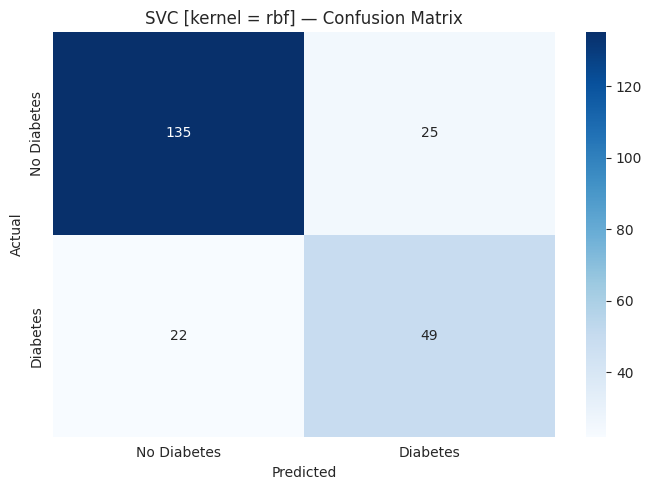

In [10]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVC [kernel = rbf] — Confusion Matrix')
plt.tight_layout()
plt.show()

## 10. Train SVM with the **Linear** kernel

The linear kernel is faster and often gives comparable accuracy on medical
datasets.  The Lab Book compares both on page 36-37.

In [11]:
model_lin = SVC(kernel='linear', random_state=0)
model_lin.fit(X_train_scaled, y_train)
y_pred_lin = model_lin.predict(X_test_scaled)

print(f"First 20 predictions (linear): {y_pred_lin[:20]}")

First 20 predictions (linear): [0 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 0 1 0 0]


## 11. Evaluation — Linear kernel

In [12]:
cm_lin = confusion_matrix(y_test, y_pred_lin)
print("SVC [kernel = linear]")
print("Confusion Matrix:")
print(cm_lin)

acc_lin  = accuracy_score(y_test, y_pred_lin)
prec_lin = precision_score(y_test, y_pred_lin)
rec_lin  = recall_score(y_test, y_pred_lin)
f1_lin   = f1_score(y_test, y_pred_lin)

print(f"\nAccuracy  : {acc_lin:.4f}  ({acc_lin*100:.2f}%)")
print(f"Precision : {prec_lin:.4f}")
print(f"Recall    : {rec_lin:.4f}")
print(f"F1 Score  : {f1_lin:.4f}")

print("\nClassification Report:")
print(classification_report(y_pred_lin, y_test))

SVC [kernel = linear]
Confusion Matrix:
[[136  24]
 [ 23  48]]

Accuracy  : 0.7965  (79.65%)
Precision : 0.6667
Recall    : 0.6761
F1 Score  : 0.6713

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.85       159
           1       0.68      0.67      0.67        72

    accuracy                           0.80       231
   macro avg       0.76      0.76      0.76       231
weighted avg       0.80      0.80      0.80       231



## 12. Confusion Matrix Heatmap — Linear

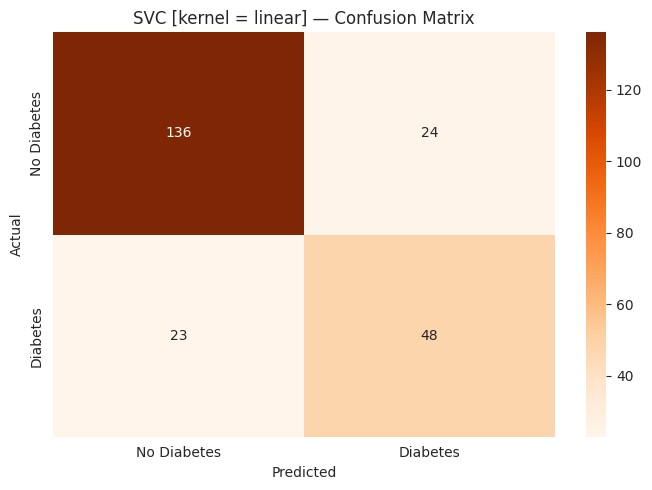

In [13]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm_lin, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVC [kernel = linear] — Confusion Matrix')
plt.tight_layout()
plt.show()

## 13. Kernel Comparison

Side-by-side bar chart of accuracy / precision / recall / F1 for both kernels.

,Kernel,Accuracy,Precision,Recall,F1
0,RBF,0.796537,0.662162,0.690141,0.675862
1,Linear,0.796537,0.666667,0.676056,0.671329


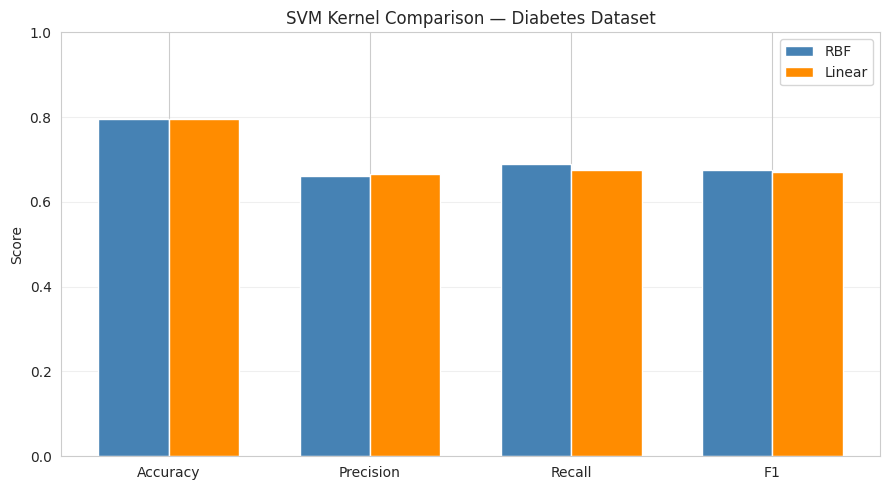

In [14]:
import pandas as pd
comparison = pd.DataFrame({
    'Kernel'   : ['RBF', 'Linear'],
    'Accuracy' : [acc_rbf,  acc_lin],
    'Precision': [prec_rbf, prec_lin],
    'Recall'   : [rec_rbf,  rec_lin],
    'F1'       : [f1_rbf,   f1_lin],
})
display(comparison)

# Bar chart
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics_list))
w = 0.35
plt.figure(figsize=(9, 5))
plt.bar(x - w/2, [acc_rbf, prec_rbf, rec_rbf, f1_rbf],  w, label='RBF',   color='steelblue')
plt.bar(x + w/2, [acc_lin, prec_lin, rec_lin, f1_lin], w, label='Linear', color='darkorange')
plt.xticks(x, metrics_list)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('SVM Kernel Comparison — Diabetes Dataset')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Decision-Boundary Visualisation (2D)

To make the boundary visible we retrain on just **glucose** and **bmi** (the
two most important features) using both kernels, then plot the resulting
decision boundaries over a scatter of the test set.

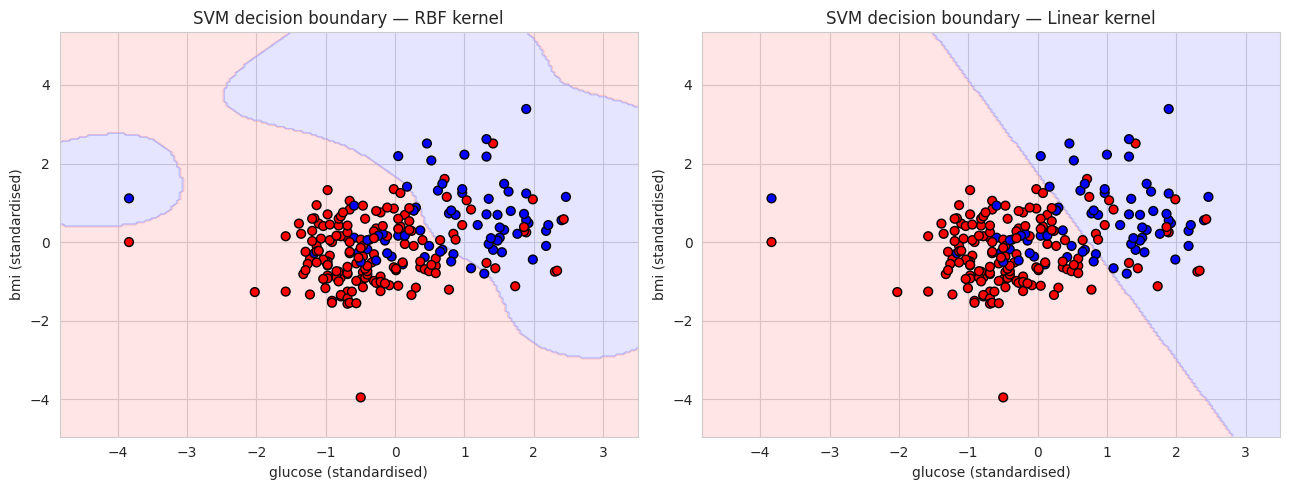

In [15]:
from matplotlib.colors import ListedColormap

X_2d = data[['glucose', 'bmi']].values
y_2d = data['label'].values
X_tr, X_te, y_tr, y_te = train_test_split(X_2d, y_2d, test_size=0.3, random_state=5)
sc2 = StandardScaler()
X_tr_s = sc2.fit_transform(X_tr)
X_te_s = sc2.transform(X_te)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, kernel, name in zip(axes, ['rbf', 'linear'], ['RBF', 'Linear']):
    m = SVC(kernel=kernel, random_state=0)
    m.fit(X_tr_s, y_tr)
    # decision boundary
    x_min, x_max = X_tr_s[:, 0].min() - 1, X_tr_s[:, 0].max() + 1
    y_min, y_max = X_tr_s[:, 1].min() - 1, X_tr_s[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                        np.linspace(y_min, y_max, 200))
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA','#AAAAFF']))
    ax.scatter(X_te_s[:, 0], X_te_s[:, 1], c=y_te, cmap=ListedColormap(['#FF0000','#0000FF']),
               edgecolors='k', s=40)
    ax.set_xlabel('glucose (standardised)')
    ax.set_ylabel('bmi (standardised)')
    ax.set_title(f'SVM decision boundary — {name} kernel')
plt.tight_layout()
plt.show()

## 📝 Exercises (Lab Book §8.6, page 37)

> Submit the Colab link or GitHub link or any `.ipynb` file for the exercises.

1. **Quadratic distribution.** Generate a random 2-D dataset that follows a
   quadratic decision boundary (e.g. `y = x² + noise`).  Train an SVM with an
   RBF kernel and visualise the resulting non-linear decision boundary.
2. **Spam classification.** Using SVM, classify emails as **spam / not-spam**
   based on features such as word-frequency and message length.  Use the
   public *Spambase* dataset from the UCI repository for this exercise.


## 📚 Key Takeaways

- **SVM** finds the hyperplane that **maximises the margin** between classes;
  the data points on the margin are the *support vectors*.
- The **kernel trick** lets SVM learn **non-linear** decision boundaries
  without explicitly projecting features.
- **RBF** is the default kernel — it captures non-linear relationships but
  is slower on large datasets.  **Linear** is faster and often equally
  accurate when classes are nearly linearly separable.
- Always **standardise features** before training an SVM.
- Regularisation parameter **C** controls the margin–violation trade-off.


## 🔗 References

- Lab Activity Book (23CSE301), §8 Support Vector Machines, page 31–37.
- Scikit-learn user guide — Support Vector Machines:
  <https://scikit-learn.org/stable/modules/svm.html>
